<a href="https://colab.research.google.com/github/sandrahany00/Teeth_classification/blob/main/Teeth_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# from google.colab import files
# files.upload()

In [ ]:
import zipfile
import os

zip_file_path = '/content/Teeth DataSet.zip'
output_dir = '/content/Teeth DataSet'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"File unzipped to {output_dir}")

File unzipped to /content/Teeth DataSet


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
IMAGE_SIZE=(224,224)
# cnn size
BATCH_SIZE=32

In [ ]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Training",
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
)

Found 3087 files belonging to 7 classes.


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Training",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)
class_names = train_dataset.class_names
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Testing",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)
validate_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/Teeth DataSet/Teeth_Dataset/Validation",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)



Found 3087 files belonging to 7 classes.
Found 1508 files belonging to 10 classes.
Found 1028 files belonging to 7 classes.


In [ ]:
print(train_dataset.class_names)
print(test_dataset.class_names)
print(validate_dataset.class_names)


['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT', 'out', 'output', 'outputs']
['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

val_dataset = validate_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [ ]:
for images, labels in train_dataset.take(1):
    print(images.numpy().min(), images.numpy().max())


0.0 1.0


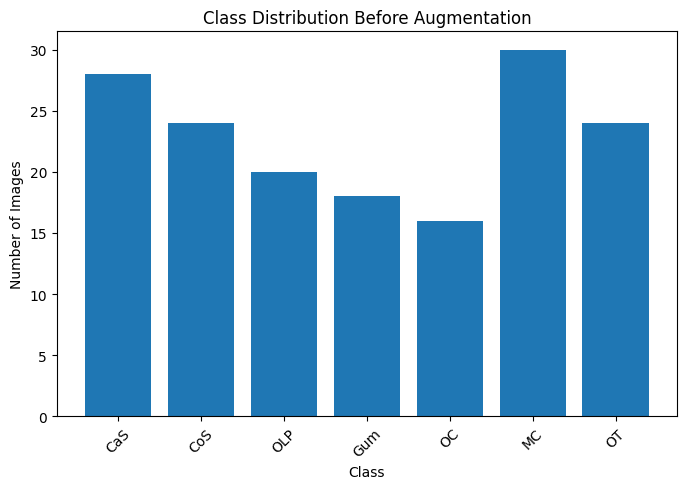

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
class_counts = {}

for images, labels in train_dataset.take(5):
    for label in labels.numpy():
        class_name = class_names[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution Before Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


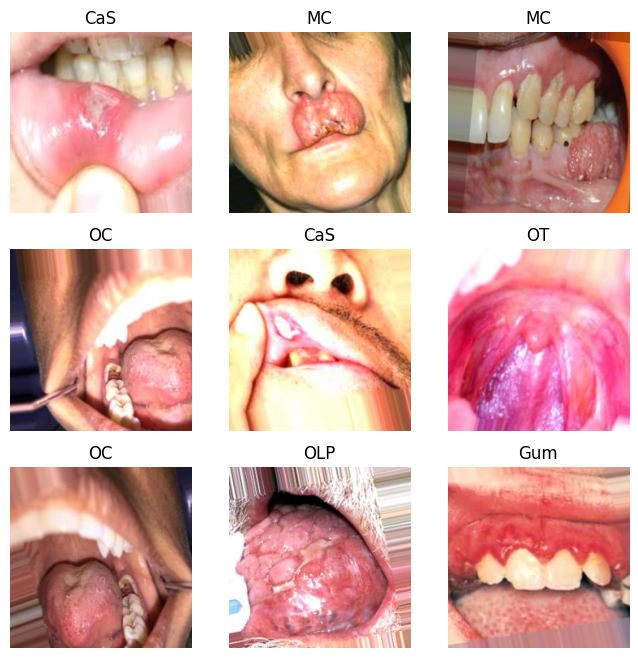

In [ ]:
plt.figure(figsize=(8, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


In [ ]:
print(class_counts)


{'CaS': 28, 'CoS': 24, 'OLP': 20, 'Gum': 18, 'OC': 16, 'MC': 30, 'OT': 24}


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.Randomflip("horizontal"),
])


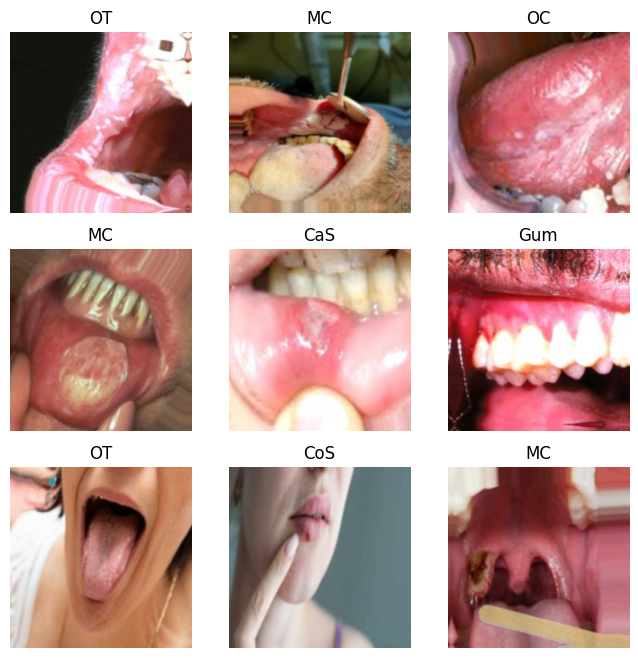

In [ ]:
plt.figure(figsize=(8, 8))
# for visualization only

for images, labels in train_dataset.take(1):
    # images=images/255.0
    augmented_images = data_augmentation(images)
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


In [ ]:
print(augmented_images[0].numpy().min(), augmented_images[0].numpy().max())


0.035810806 1.0


In [ ]:
print(class_counts)


{'CaS': 28, 'CoS': 24, 'OLP': 20, 'Gum': 18, 'OC': 16, 'MC': 30, 'OT': 24}


In [134]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_dataset.prefetch(AUTOTUNE)
val_ds   = validate_dataset.prefetch(AUTOTUNE)
test_ds  = test_dataset.prefetch(AUTOTUNE)
